# Model diagnostics (held-out CV)

Thin runner. All logic lives in `pipeline/cv_diagnostics.py`; it reads the CV outputs in `config.CV_RESULTS_DIR` (`cv_stats.csv`, `cv_zscores.pkl`, `cv_ppc.pkl`) and writes every figure to `CV_Results/Figures/` plus `cv_summary_by_stage.csv` / `ppc_summary_stats.csv`.

- Calibration: per-stage W1 / mean_z / std_z / skew_z / kurt_z (RQR z vs N(0,1)).
- Posterior predictive check: real vs simulated mean / std / detection rate, Spearman rho + RMSE + Bias (log2 for count stats, raw for detection rate; discreteness-robust) + raw-scale MAE.

In [1]:
import sys, warnings
warnings.filterwarnings('ignore')
sys.path.insert(0, '.')
sys.path.insert(0, '..')
from pipeline import cv_diagnostics as cvd

,w1,mean_z,std_z,skew_z,kurt_z,n_valid,n_genes
stage_key,,,,,,,
nbi,0.064823,0.003927,1.063991,-0.015693,0.821947,693.0,17572
nb_fixed,0.057548,0.004754,0.974226,0.209307,1.117333,693.0,1684
intercept,0.074205,-0.027244,0.943494,0.156248,1.294376,693.0,282
pool,0.059010,-0.009597,0.944842,0.061538,0.783884,693.0,559


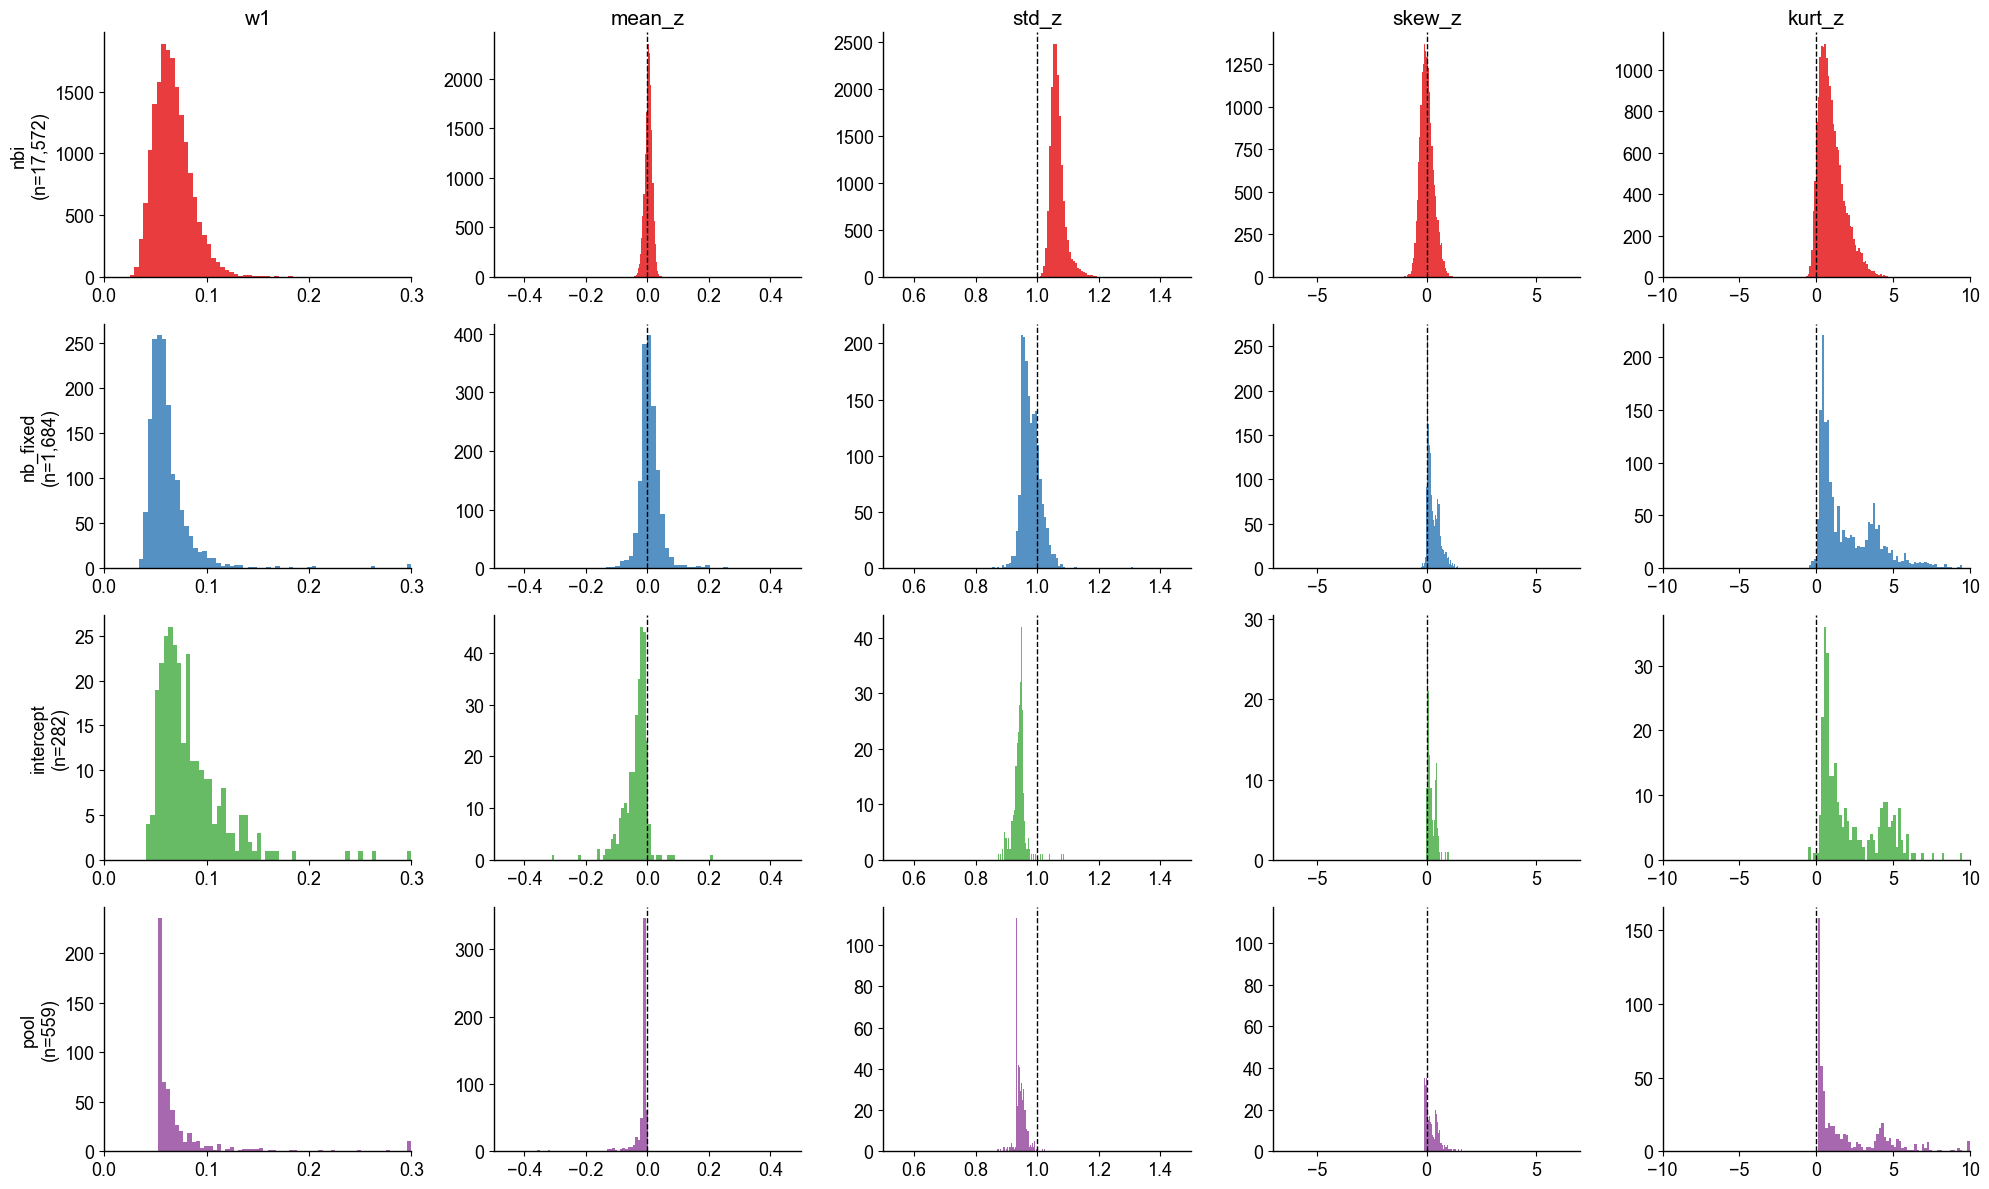

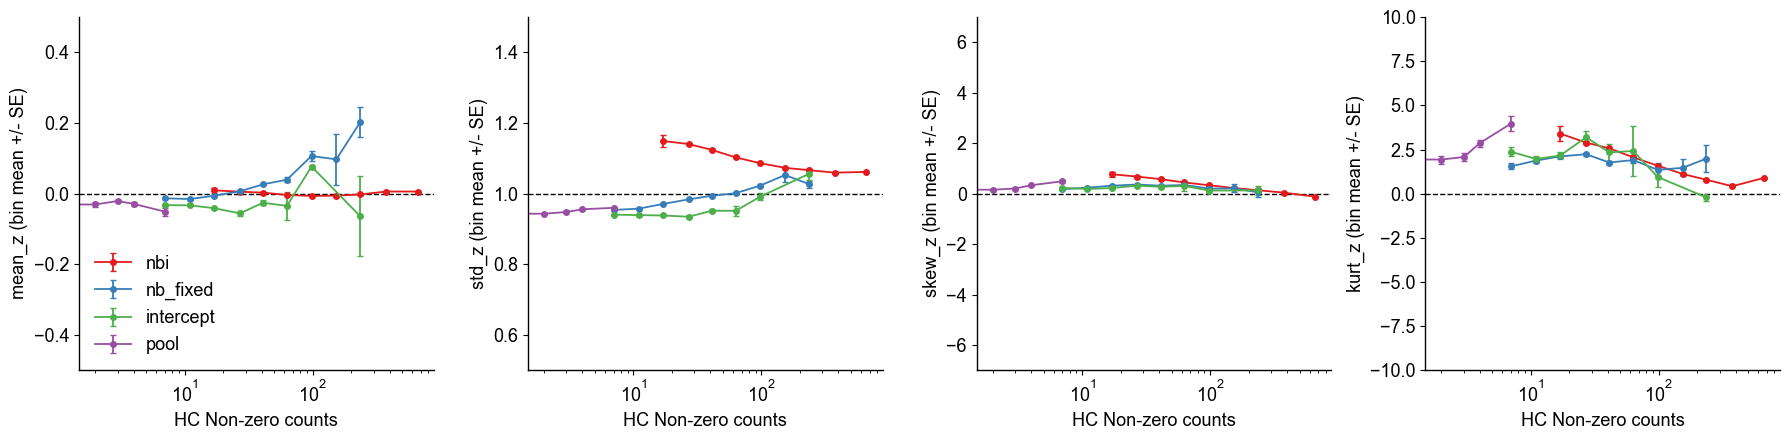

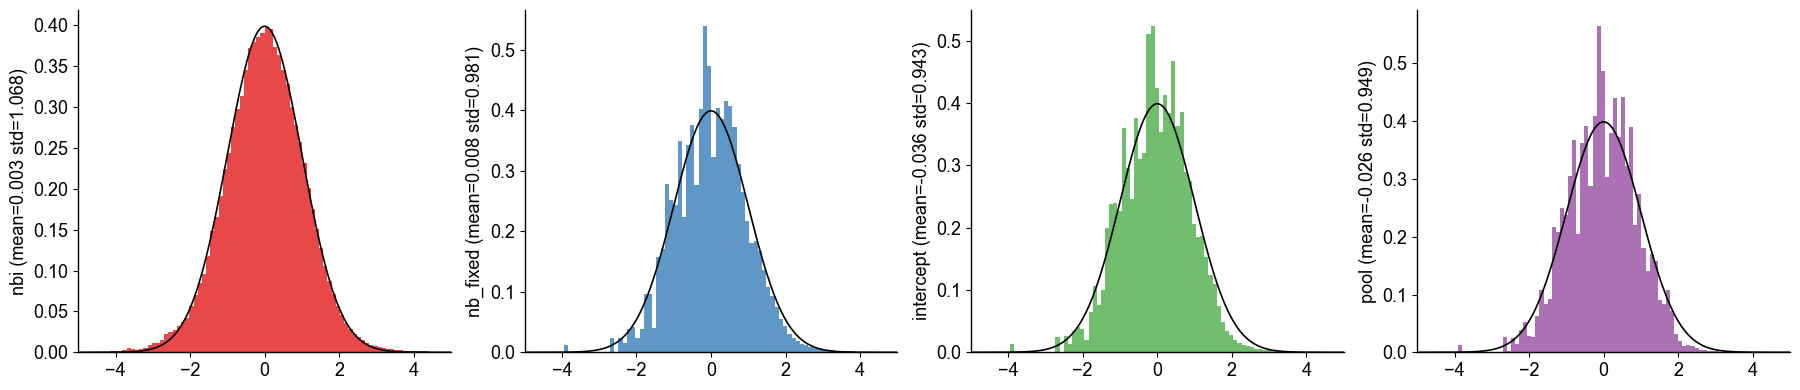

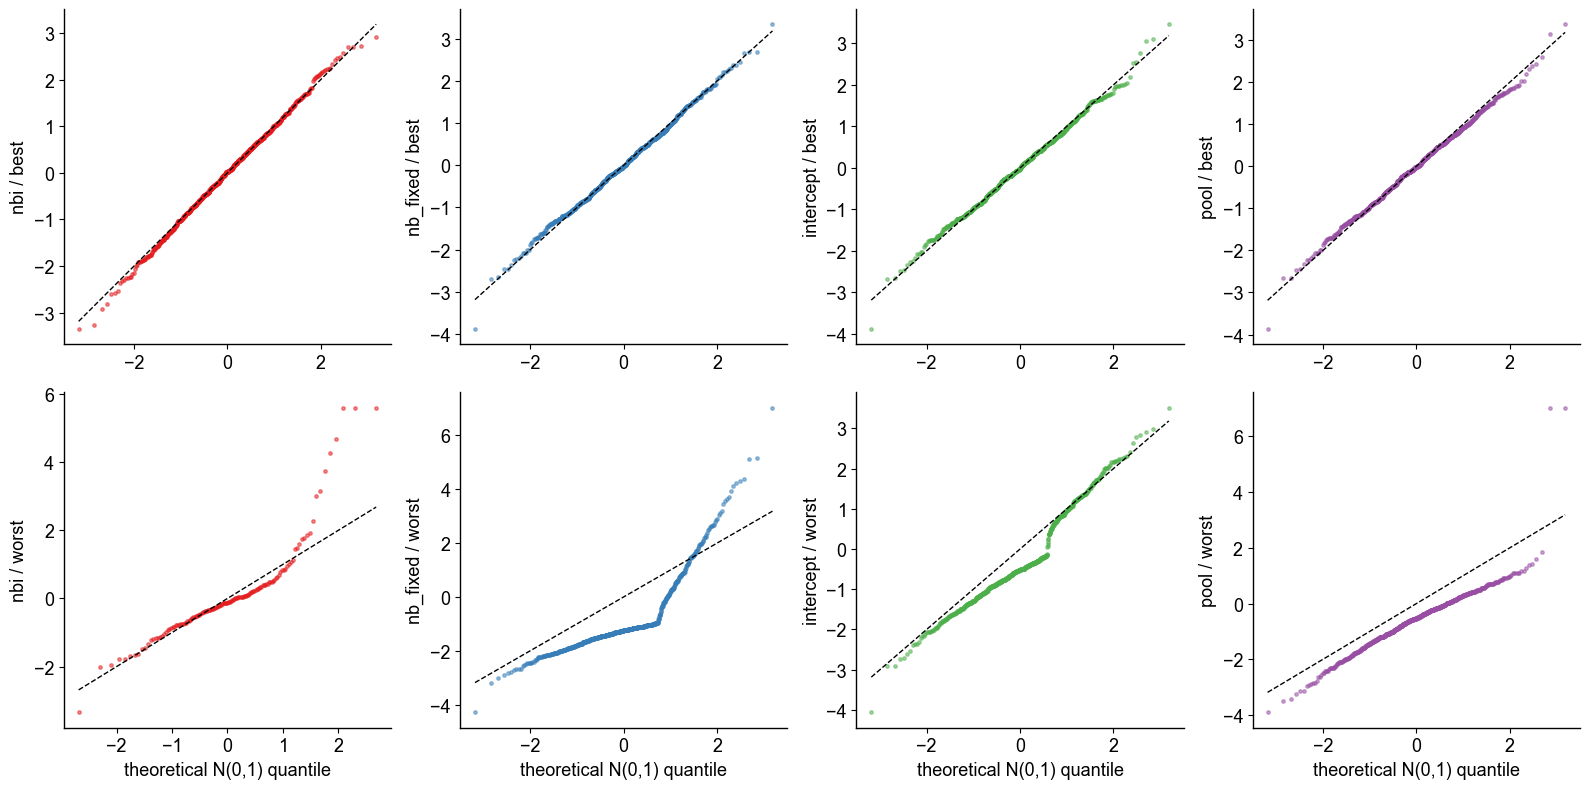

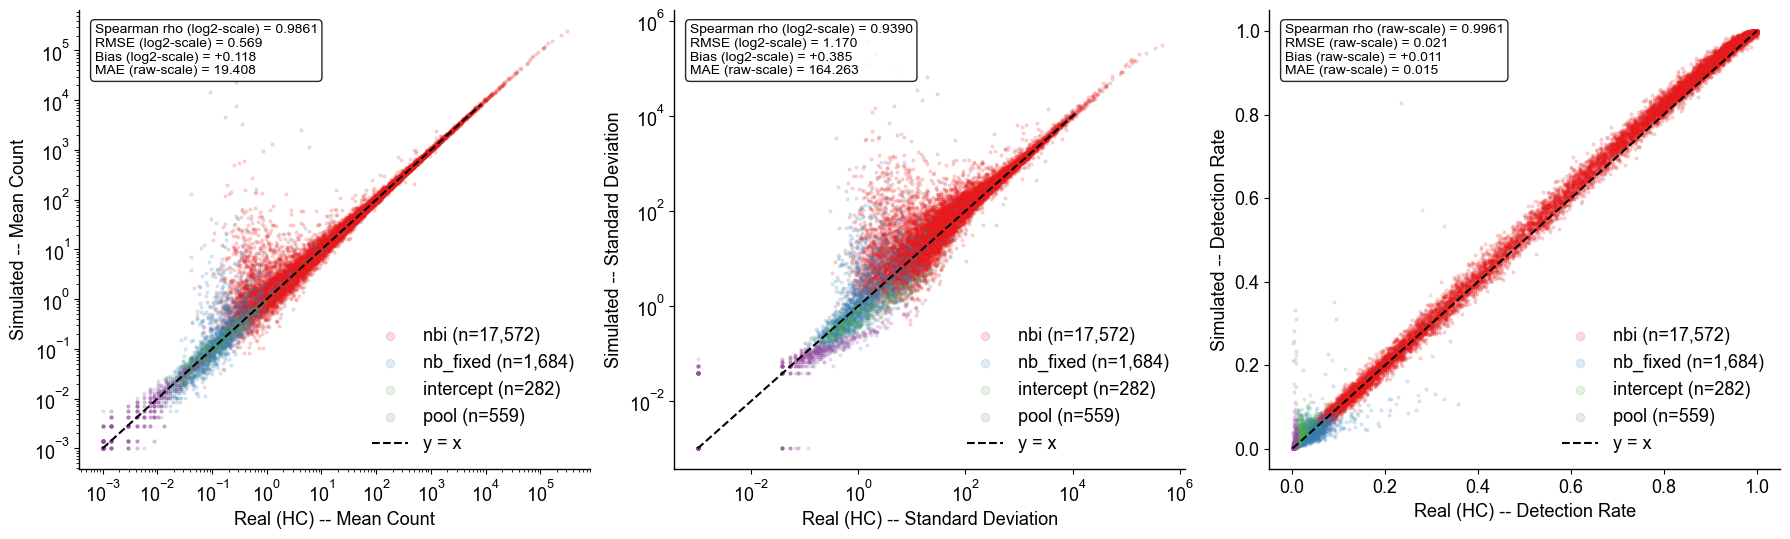

In [2]:
out = cvd.run_all()
out['summary']

In [3]:
out['ppc_stats']

,stage,statistic,spearman_rho,mae,bias,rmse
0,nbi,Mean Count,0.984096,21.291634,0.116406,0.567304
1,nb_fixed,Mean Count,0.828365,9.431395,0.189447,0.709028
2,intercept,Mean Count,0.968738,0.048018,0.003050,0.053881
3,pool,Mean Count,0.931483,0.002930,-0.000059,0.006443
4,ALL,Mean Count,0.986086,19.407585,0.117696,0.568828
5,nbi,Standard Deviation,0.925728,164.282244,0.414914,1.149899
6,nb_fixed,Standard Deviation,0.751743,245.645847,0.412776,1.542669
7,intercept,Standard Deviation,0.929768,2.027486,-0.514551,0.755717
8,pool,Standard Deviation,0.918465,0.332872,-0.184214,0.471516
9,ALL,Standard Deviation,0.938971,164.262976,0.385027,1.170363
